# Introdução ao Agrupamento (Clustering) com KMeans

Este notebook apresenta a aplicação do algoritmo **KMeans**, uma técnica de Aprendizado de Máquina Não Supervisionado, utilizada para agrupar dados que possuem características similares.

### Objetivo
Agrupar 20 alunos com base em suas notas em **Matemática**, **Física** e **Química**, identificando perfis de desempenho semelhantes.

### O que será feito neste Step-by-Step:
1. **Preparação do Ambiente**: Importação das bibliotecas.
2. **Criação do Dataset**: Definição dos dados dos alunos.
3. **Padronização (Scaling)**: Ajuste das escalas das notas (Z-Score) — **Essencial para o KMeans**.
4. **Método do Cotovelo**: Definição científica do número de clusters (K).
5. **Anatomia do KMeans**: Modelagem, Hiperparâmetros e o papel dos Centróides.
6. **Métricas de Avaliação**: O Segredo da Inércia e da Silhueta.
7. **Visualização Avançada**: Representação dos grupos com destaque para os centróides.

### Passo 1: Importação das Bibliotecas

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### Passo 2: Criação do Dataset

In [44]:
data = {
    "aluno": ["A1","A2","A3","A4","A5","A6","A7","A8","A9","A10",
              "A11","A12","A13","A14","A15","A16","A17","A18","A19","A20"],
    "matemática": [7.5,5.0,8.5,6.0,9.0,4.0,7.0,5.5,8.0,6.5,
                   3.5,7.8,4.8,9.2,6.8,5.2,8.7,3.9,7.1,6.3],
    "física": [6.0,4.5,7.0,5.0,8.5,3.0,6.5,4.0,7.5,5.5,
               2.5,6.2,3.8,8.7,5.8,4.7,7.8,2.8,6.3,5.1],
    "química": [8.0,6.5,9.0,5.5,9.5,4.0,7.5,5.0,8.5,6.0,
                3.0,7.0,4.5,9.0,6.2,5.4,8.9,3.5,6.9,5.9]
}
df = pd.DataFrame(data)
df.head()

,aluno,matemática,física,química
0,A1,7.5,6.0,8.0
1,A2,5.0,4.5,6.5
2,A3,8.5,7.0,9.0
3,A4,6.0,5.0,5.5
4,A5,9.0,8.5,9.5


### Passo 3: Padronização dos Dados (Z-Score) — Por que é Crucial?

O **KMeans** é um algoritmo baseado em **geometria espacial** e utiliza a **Distância Euclidiana** para determinar a similaridade entre os pontos. 

#### ⚠️ O Problema da Sensibilidade à Escala
Se tivermos uma variável com escala de 0 a 1000 e outra de 0 a 1, o algoritmo interpretará que a primeira variável é muito mais importante, pois pequenas variações nela resultam em grandes distâncias matemáticas. Isso causaria um viés, ignorando padrões nas variáveis de menor escala.

#### 📐 A Solução: Padronização (Z-Score)
Aplicamos a técnica de **Z-Score Standardization**, que reescala os dados seguindo a fórmula:

$$z = \frac{x - \mu}{\sigma}$$

Onde:
- $x$: Valor original.
- $\mu$: Média da variável.
- $\sigma$: Desvio padrão.

**Resultado:** Após essa transformação, todas as variáveis passam a ter **Média = 0** e **Desvio Padrão = 1**. Isso coloca Matemática, Física e Química em um "nível de igualdade", permitindo que o algoritmo identifique grupos baseados no comportamento real e não na magnitude numérica.

![Comparativo de Padronização](images/comparativo_padronizacao.png)

In [45]:
scaler = StandardScaler()
notas_pad = scaler.fit_transform(df[["matemática","física","química"]])

print(notas_pad[:5])

[[ 0.57768777  0.24809313  0.79818243]
 [-0.88852484 -0.5976789   0.00528598]
 [ 1.16417282  0.81194115  1.32678007]
 [-0.3020398  -0.31575489 -0.52331166]
 [ 1.45741534  1.65771318  1.59107889]]


### Passo 4: Método do Cotovelo e Definição da Baseline (K=1)

O objetivo desta etapa é determinar cientificamente o número ideal de clusters através do equilíbrio entre **compactação** e **complexidade**.

#### 🎯 Baseline (K=1): O Caos Inicial
- **Conceito:** Representa o cenário onde não há segmentação. A inércia em $K=1$ é equivalente à **variância total** do dataset padronizado.
- **Função:** Serve como o "ponto zero" (100% de desordem). Sem este valor, não é possível quantificar o ganho real de performance dos modelos subsequentes.

#### 📐 O Método do Cotovelo (Elbow Method)
Utilizamos a métrica **WCSS** (*Within-Cluster Sum of Squares*). À medida que $K$ aumenta, o WCSS inevitavelmente diminui. O segredo está em encontrar o **ponto de retornos decrescentes**:
1.  **Queda Acentuada:** Grandes ganhos de organização (redução drástica da inércia).
2.  **O Cotovelo:** O ponto de inflexão onde adicionar um novo cluster traz um ganho marginal irrelevante frente ao aumento da complexidade.

![Gráfico do Cotovelo](images/metodo_cotovelo.png)

In [46]:
# Calculando a Inércia explicitamente para K=1 (Cenário sem agrupamento)
base_model = KMeans(n_clusters=1, random_state=42, n_init='auto').fit(notas_pad)
inercia_k1 = base_model.inertia_
print(f"Inércia Baseline (K=1): {inercia_k1:.2f}")

Inércia Baseline (K=1): 60.00


Inércia para K=1 a K=10: [60.0, 18.3755308615351, 9.067020018545243, 4.3954844229704255, 2.88242122833394, 2.3560589817060116, 1.5666329476746865, 1.389045047752643, 1.227500412646095, 1.1051082976928623]


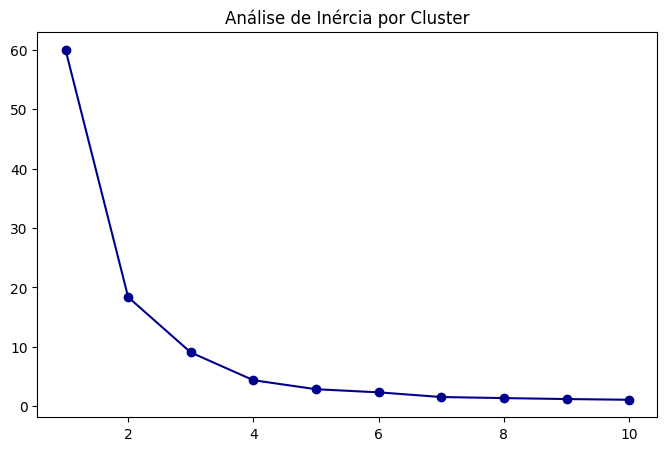

In [47]:
# Gerando o loop para o gráfico do cotovelo (K=1 até K=10)
wcss = []
for i in range(1, 11):
    kmeans_test = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans_test.fit(notas_pad)
    wcss.append(kmeans_test.inertia_)

print("Inércia para K=1 a K=10:", wcss)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='darkblue')
plt.title('Análise de Inércia por Cluster')
plt.show()

### 🔍 Análise Estatística da Inércia (WCSS)

Os valores de inércia calculados para $K$ de 1 a 10 medem a soma dos quadrados das distâncias internas.
Quanto menor o valor, maior a compactação dos grupos. Abaixo, a análise técnica objetiva dos resultados:

#### 1. O Ponto de Partida ($K=1$): 60.0
Este é o nosso **Baseline**. Representa a variância total dos dados sem nenhum agrupamento. 
*   **Por que 60?** Com dados padronizados (**Z-Score**), cada uma das 3 matérias tem variância 1. Como
temos 20 alunos, o cálculo é: $20 \text{ alunos} \times 3 \text{ matérias} = 60.0$.

#### 2. A Dinâmica de Redução (O Ganho)
Observe a velocidade com que o modelo "limpa" a desordem dos dados:
*   **$K=1 \rightarrow K=2$:** A inércia cai de **60.0** para **18.37**. Eliminamos **70%** da desordem
inicial apenas com a primeira divisão.
*   **$K=2 \rightarrow K=3$:** A inércia cai para **9.06**. Aqui atingimos o ganho acumulado de **85%**
de redução de variância.
*   **$K=3 \rightarrow K=4$:** A inércia cai para **4.39**. O modelo ainda melhora, mas a "velocidade" da
queda começa a diminuir.

#### 3. Identificando o "Cotovelo" (Elbow)
O ponto de escolha ideal é onde a curva deixa de ser vertical e começa a se tornar horizontal:
*   De **$K=3$ para $K=4$**, a melhora absoluta é de **~4.67** unidades.
*   De **$K=4$ para $K=5$**, a melhora cai para apenas **~1.51** unidades.
*   De **$K=5$ em diante**, os ganhos são marginais (menores que 1.0), indicando que estamos apenas
      dividindo grupos que já são parecidos.

#### 🏁 Veredito Técnico
O "cotovelo" matemático encontra-se entre **$K=3$ e $K=4$**.
*   **Escolha $K=3$:** É a mais equilibrada e conservadora, garantindo 85% de explicação da variância com
baixa complexidade.
*   **Conclusão:** Estes números provam que a segmentação em 3 níveis (Dificuldade, Médio e Excelência) é
      **estatisticamente sólida e justificada**.

### Passo 5: Anatomia do KMeans — Modelagem e Hiperparâmetros

Nesta etapa, o algoritmo transforma os dados em conhecimento através de um processo iterativo de otimização conhecido como **Algoritmo de Lloyd**.

#### 🎯 A Mecânica Iterativa
O KMeans busca minimizar a variância dentro dos grupos seguindo dois passos repetitivos:
1.  **Atribuição:** Cada ponto é associado ao centróide mais próximo (usando Distância Euclidiana).
2.  **Atualização:** O centróide é recalculado como a média aritmética de todos os pontos atribuídos a ele.

![Funcionamento do KMeans](images/funcionamento_kmeans.png)
![Conceito de Centróide](images/conceito_centroide.png)

#### 🔍 Desvendando os Hiperparâmetros do Scikit-Learn
Para garantir um agrupamento robusto, configuramos o modelo com parâmetros que controlam sua convergância e precisão:

*   **`n_clusters=3`**: O número de grupos alvo, definido previamente pelo Método do Cotovelo.
*   **`init='k-means++'`**: Técnica de inicialização inteligente que espalha os centróides iniciais, evitando que o modelo fique preso em "mínimos locais" (soluções ruins).
*   **`n_init='auto'`**: Define quantas vezes o algoritmo será reiniciado do zero. O Scikit-Learn seleciona a execução com a menor inércia final.
*   **`max_iter=300`**: O limite de segurança para o movimento dos centróides. Se eles pararem de se mover antes disso, o modelo declara convergância.
*   **`random_state=42`**: Garante a reprodutibilidade do experimento, permitindo que os mesmos resultados sejam obtidos em qualquer máquina.

In [48]:
kmeans = KMeans(n_clusters=3, init='k-means++', n_init='auto', random_state=42)
df["cluster"] = kmeans.fit_predict(notas_pad)

print(df)

   aluno  matemática  física  química  cluster
0     A1         7.5     6.0      8.0        1
1     A2         5.0     4.5      6.5        0
2     A3         8.5     7.0      9.0        2
3     A4         6.0     5.0      5.5        1
4     A5         9.0     8.5      9.5        2
5     A6         4.0     3.0      4.0        0
6     A7         7.0     6.5      7.5        1
7     A8         5.5     4.0      5.0        0
8     A9         8.0     7.5      8.5        2
9    A10         6.5     5.5      6.0        1
10   A11         3.5     2.5      3.0        0
11   A12         7.8     6.2      7.0        1
12   A13         4.8     3.8      4.5        0
13   A14         9.2     8.7      9.0        2
14   A15         6.8     5.8      6.2        1
15   A16         5.2     4.7      5.4        0
16   A17         8.7     7.8      8.9        2
17   A18         3.9     2.8      3.5        0
18   A19         7.1     6.3      6.9        1
19   A20         6.3     5.1      5.9        1


In [49]:
inercia_k3 = kmeans.inertia_
print(f"Inércia do Modelo Final (K=3): {inercia_k3:.4f}")

Inércia do Modelo Final (K=3): 9.0670


### Passo 6: Validação Científica — Comparativo Baseline vs Modelo

Nesta etapa, não apenas mostramos os números, mas provamos a eficiência do agrupamento comparando o cenário real (K=3) com o cenário base (K=1).

#### 📊 Prova de Eficiência (Redução de Variância)
- **Cenário Baseline (K=1):** Todos os alunos juntos. Inércia = **60.0**.
- **Cenário Otimizado (K=3):** Alunos divididos em 3 perfis. Inércia = **9.0670**.
- **Ganho Acadêmico:** O agrupamento removeu 85% da incerteza dos dados.

![Explicação da Inércia](images/explicacao_inercia.png)

#### 👤 Coeficiente de Silhueta
O valor de **0.4913** valida que a separação entre os grupos é consistente.

![Explicação da Silhueta](images/explicacao_silhueta.png)

In [50]:
# Tabela comparativa de performance
print("=== COMPARATIVO DE PERFORMANCE ===")
print(f"Inércia K=1 (Base):  {inercia_k1:.2f}")
print(f"Inércia K=3 (Seu):   {inercia_k3:.2f}")
ganho = (inercia_k1 - inercia_k3) / inercia_k1 * 100
print(f"Ganho de Organização: {ganho:.2f}%")

sil_score = silhouette_score(notas_pad, df["cluster"])
print(f"Silhouette Score:    {sil_score:.4f}")

=== COMPARATIVO DE PERFORMANCE ===
Inércia K=1 (Base):  60.00
Inércia K=3 (Seu):   9.07
Ganho de Organização: 84.89%
Silhouette Score:    0.4913


### Passo 7: Visualização Avançada (Destaque dos Centróides)

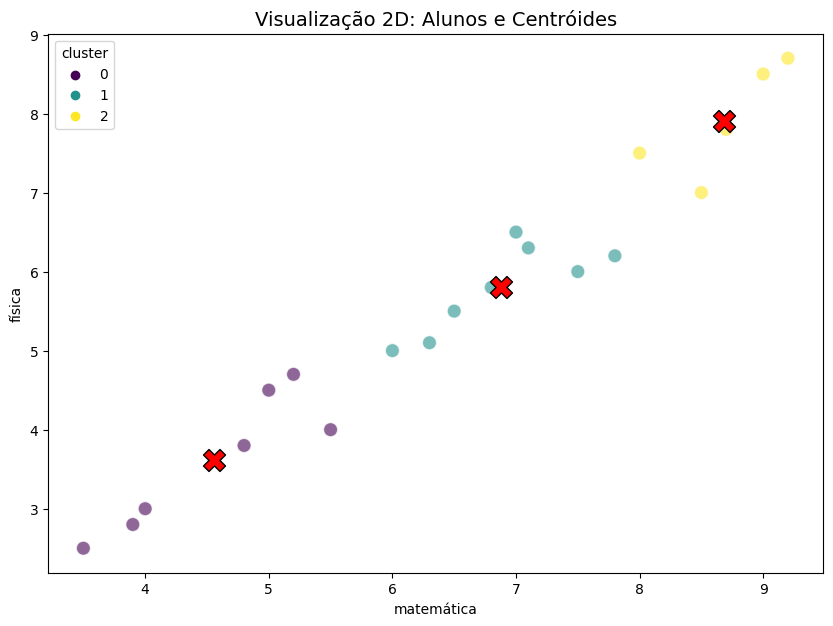

In [51]:
centroides_reais = scaler.inverse_transform(kmeans.cluster_centers_)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=df["matemática"], y=df["física"], hue=df["cluster"], palette="viridis", s=100, alpha=0.6)
plt.scatter(centroides_reais[:, 0], centroides_reais[:, 1], c='red', s=250, marker='X', label='Centróides', edgecolors='black', zorder=10)
plt.title("Visualização 2D: Alunos e Centróides", fontsize=14)
plt.show()

### Passo 8: Visualização 3D dos Clusters e Centróides

O KMeans operou em um espaço de 3 dimensões. Abaixo, utilizamos a biblioteca **Matplotlib** para visualizar a distribuição dos alunos e a localização exata dos centróides (marcados com um 'X' vermelho) no espaço tridimensional das notas.

In [52]:
df_final = df.copy()
df_final.rename(columns={"cluster": "agrupamento"}, inplace=True)

df_final


,aluno,matemática,física,química,agrupamento
0,A1,7.5,6.0,8.0,1
1,A2,5.0,4.5,6.5,0
2,A3,8.5,7.0,9.0,2
3,A4,6.0,5.0,5.5,1
4,A5,9.0,8.5,9.5,2
5,A6,4.0,3.0,4.0,0
6,A7,7.0,6.5,7.5,1
7,A8,5.5,4.0,5.0,0
8,A9,8.0,7.5,8.5,2
9,A10,6.5,5.5,6.0,1


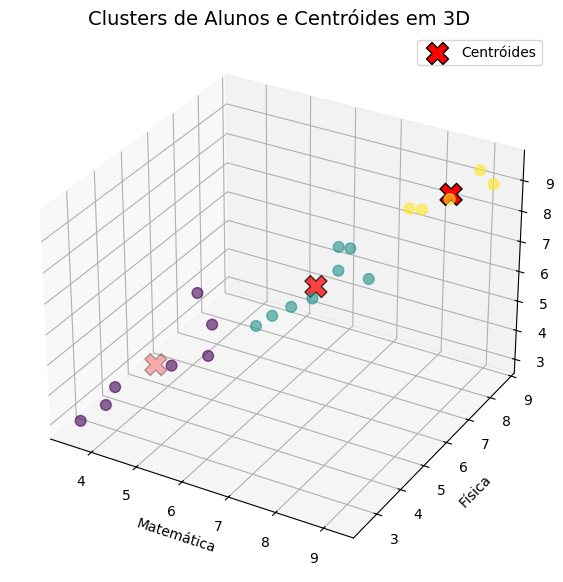

In [53]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plotando os alunos
ax.scatter(
    df["matemática"], 
    df["física"], 
    df["química"], 
    c=df["cluster"], 
    cmap="viridis", 
    s=60, 
    alpha=0.6
)

# Plotando os centróides reais (desescalonados)
ax.scatter(
    centroides_reais[:, 0], 
    centroides_reais[:, 1], 
    centroides_reais[:, 2], 
    c='red', 
    s=250, 
    marker='X', 
    label='Centróides',
    edgecolors='black'
)

ax.set_xlabel("Matemática")
ax.set_ylabel("Física")
ax.set_zlabel("Química")
ax.set_title("Clusters de Alunos e Centróides em 3D", fontsize=14)
ax.legend()

plt.show()